# 🩺 Logistic Regression — Intuition, Math & Project

### From "what is it" to "how do I build one" — a complete, end-to-end walkthrough

This notebook covers Logistic Regression:
starting with pure intuition (zero math), then the actual mathematics behind it, a
tiny hand-solved example, and finally a full production-style machine learning
pipeline on a real dataset — the **UCI Heart Disease dataset**.

---

## 📑 Table of Contents

1. [What Is Logistic Regression?](#section1)
2. [The Story — Dr. Sarah's Diagnosis Journey](#section2)
3. [Pros & Cons](#section3)
4. [The Math Behind It](#section4)
5. [Hand-Solved Example (Gradient Descent, step by step)](#section5)
6. [Decision Boundary & Threshold](#section6)
7. [Regularization: Ridge vs Lasso vs ElasticNet](#section7)
8. [Precision, Recall & the Trade-off](#section8)
9. [Bias-Variance Tradeoff (quick note)](#section9)
10. [Building the Real Project — Heart Disease Prediction](#section10)
11. [Summary & Key Takeaways](#section11)


<a id="section1"></a>
## 1️⃣ What Is Logistic Regression?

Logistic Regression is a **classification algorithm** — it predicts which of two
(or more) categories something belongs to (spam/not-spam, disease/healthy,
pass/fail). Unlike a simple yes/no answer, it outputs a **probability** (e.g.
"73% chance this is spam"), and only converts that probability into a final
category **as an extra, optional step**.

Despite the word "Regression" in its name, it is fundamentally a **classification**
tool.

<a id="section2"></a>
## 2️⃣ The Story — Dr. Sarah's Diagnosis Journey

### Chapter 1 — A New Doctor, A New Job

Dr. Sarah just joined a clinic. Her job: look at a patient's symptoms
(temperature, cough severity, body ache) and decide — **"Does this patient have
the flu?"**

At first she gives blunt Yes/No answers. But she quickly realizes real life
isn't black-and-white — some patients look mildly sick, others clearly very
sick. A plain Yes/No throws away useful information. She needs a way to say
**"how confident am I?"**

### Chapter 2 — First Attempt: A Straight Line (and why it fails)

Sarah's first idea (essentially **Linear Regression**) is to build a raw score
from the symptoms:

$$z = w_1 \cdot \text{temperature} + w_2 \cdot \text{cough} + b$$

The problem: for a very sick patient this raw score can shoot up to **150%**,
and for a healthy one it can go to **-30%**. A confidence score can never be
above 100% or below 0% — this approach is fundamentally broken for
probabilities.

### Chapter 3 — The Fix: A "Confidence Dial" (Sigmoid)

A senior colleague shows her a trick: a **squishing dial** that takes *any*
number — however large or small — and always compresses it into the **0% to
100%** range. This is the **Sigmoid function**.

```
Confidence
  100% |                        ______------
       |                   ___/
   75% |                _/
       |              /
   50% |------------●--------------------   <- the "undecided" midpoint
       |          /
   25% |       _/
       |   ___/
    0% |__/
       +------------------------------------
          Fewer symptoms  ->  More symptoms
```

Now her process is: (1) combine symptoms into a raw score `z` (Chapter 2's
formula), (2) pass it through the Sigmoid dial, (3) get a clean 0–100%
probability.

### Chapter 4 — Turning Probability into a Decision (Threshold)

Sarah still needs a final Yes/No answer for the patient. So she sets a **rule**:

> If probability ≥ 50% → "Yes, flu"
> If probability < 50% → "No, not flu"

This 50% cutoff is called the **decision boundary / threshold**. It doesn't
have to be 50% — for something high-stakes like cancer screening, she might
lower it to 30% to avoid missing any real cases.

**Important:** the model itself never outputs "Yes/No" — it only ever outputs a
continuous probability (0.01, 0.5, 0.87, anything in between). The threshold is
a separate, human-chosen rule applied *after* prediction, purely at inference
time — it plays no role during training.

### Chapter 5 — Learning From Mistakes: "Confidently Wrong" Hurts More

After each patient, Sarah gets feedback on whether she was right. But not all
mistakes feel the same:

- **95% confident, correct** → small reward, she's doing great.
- **55% confident, wrong** → a light tap on the wrist, she wasn't very sure anyway.
- **95% confident, WRONG** → a serious wake-up call — being confidently wrong
  is the worst kind of mistake.

```
   PUNISHMENT METER

   Low confidence + wrong        High confidence + wrong
   [slight frown]  <----------------->  [big alarm!]
```

This "confidently wrong hurts more" intuition is exactly what the **Log Loss**
function formalizes mathematically (Section 4).

### Chapter 6 — Years of Practice = A Trained Model

After seeing hundreds of patients, Sarah's internal formula (how much weight
to give each symptom) becomes finely tuned. This gradual, repeated
"predict → get feedback → adjust weights" loop is exactly **Gradient Descent**,
and it's how Logistic Regression is trained.


<a id="section3"></a>
## 3️⃣ Pros & Cons

### ✅ Pros
- **Fast and lightweight** — trains quickly even on modest hardware and small datasets.
- **Gives a probability, not just a label** — "82% chance" is far more useful than a blunt Yes/No, especially for risk-based decisions.
- **Explainable** — each feature has a clear weight; you can literally say "temperature matters more than cough" — no black box.
- **Relatively resistant to overfitting on small/clean datasets** because the model is intentionally simple (a straight-line decision boundary, squished through Sigmoid).

### ❌ Cons
- **Linear decision boundary** — if the real relationship between features and the outcome is highly non-linear or involves complex interactions, Logistic Regression will underperform tree-based or neural models.
- **Sensitive to outliers** — one extreme data point can meaningfully shift the learned weights.
- **Struggles with very high-dimensional data** without regularization or feature selection.
- **Assumes features contribute somewhat independently** — real-world features are often correlated, which can destabilize the learned weights (see multicollinearity).


<a id="section4"></a>
## 4️⃣ The Math Behind It

### 4.1 — Which "Regression" Is It Built On?

The raw score formula:

$$z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b$$

is **exactly** the plain (vanilla) Linear Regression formula — no penalty, just
a weighted sum. This is the foundation. Logistic Regression = this linear
formula **+ Sigmoid squish + Log Loss training** (instead of MSE).

By default, scikit-learn's `LogisticRegression()` applies an **L2 (Ridge-style)
penalty** on top of this formula — more on that in Section 7.

### 4.2 — The Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

| z | σ(z) |
|---|---|
| very negative (-10) | ≈ 0.00004 (near 0%) |
| 0 | exactly 0.5 (50%) |
| very positive (+10) | ≈ 0.99995 (near 100%) |

No matter how extreme `z` gets, the output is mathematically guaranteed to stay
strictly between 0 and 1.

### 4.3 — Log Loss (Binary Cross-Entropy)

MSE doesn't work well here (it makes the loss surface "bumpy" for gradient
descent when paired with Sigmoid). Instead we use **Log Loss** — the exact
mathematical form of "confidently wrong hurts more":

$$\text{Loss} = -\Big[y \cdot \log(\hat{y}) + (1-y) \cdot \log(1-\hat{y})\Big]$$

- If the true label $y=1$ and the model predicts $\hat{y}=0.99$ (confident and
  correct) → loss ≈ $-\log(0.99) \approx 0.01$ → tiny penalty.
- If $y=1$ but the model predicts $\hat{y}=0.01$ (confident and **wrong**) →
  loss ≈ $-\log(0.01) \approx 4.6$ → a huge penalty.

### 4.4 — Why Is It Called "Regression"?

The model's core output is **always a continuous number** — the probability
(or equivalently, the **log-odds**, $z = wx+b$). Turning that into a Yes/No
category is an *extra* step we add afterward, not something the model itself
does. Technically, Logistic Regression regresses the **log-odds** of the
probability:

$$\text{log-odds} = \log\left(\frac{\hat{y}}{1-\hat{y}}\right) = z = wx+b$$

Hence the name: **"Logistic"** (from the Sigmoid/logit function) +
**"Regression"** (because internally it predicts a continuous quantity using
the same linear-equation machinery as ordinary regression).

### 4.5 — Deriving the Gradient (Chain Rule)

We need $\dfrac{dL}{dw}$ to know how to adjust `w`. Since `w` affects `z`,
which affects `ŷ`, which affects the Loss, we use the **Chain Rule**:

$$\frac{dL}{dw} = \frac{dL}{d\hat{y}} \times \frac{d\hat{y}}{dz} \times \frac{dz}{dw}$$

**Piece 1** — differentiate the Log Loss w.r.t. $\hat{y}$:

$$\frac{dL}{d\hat{y}} = \frac{\hat{y}-y}{\hat{y}(1-\hat{y})}$$

**Piece 2** — the Sigmoid derivative (a well-known, elegant result):

$$\frac{d\hat{y}}{dz} = \hat{y}(1-\hat{y})$$

**Piece 3** — the derivative of the linear equation:

$$\frac{dz}{dw} = x$$

Multiplying all three, the $\hat{y}(1-\hat{y})$ terms **cancel out beautifully**
(this is exactly why Log Loss + Sigmoid are paired together, not MSE):

$$\frac{dL}{dw} = (\hat{y}-y) \times x$$

Similarly, $\dfrac{dL}{db} = (\hat{y}-y)$.

Defining $error = \hat{y} - y$ (predicted minus actual), and averaging over all
$n$ training examples:

$$dw = \frac{1}{n}\sum_{i=1}^{n} (error_i \times x_i), \qquad db = \frac{1}{n}\sum_{i=1}^{n} error_i$$

**Intuition:** if a feature's value ($x$) was large *and* the prediction was
badly wrong, that feature gets a large correction. If $x$ was small, that
feature is barely blamed for the error — the formula naturally assigns
"credit/blame" in proportion to how involved each feature was.


<a id="section5"></a>
## 5️⃣ Hand-Solved Example — Gradient Descent, Step by Step

**Tiny dataset:** "Hours studied (x) → Passed the exam? (y)"

| Student | Hours (x) | Passed (y) |
|---|---|---|
| A | 1 | 0 |
| B | 2 | 0 |
| C | 3 | 0 |
| D | 4 | 1 |
| E | 5 | 1 |

Start: $w=0, b=0$, learning rate = 0.1

### Epoch 1

Since $w=0,b=0$: every $z=0$, so every $\hat{y} = \sigma(0) = 0.5$ (the model is
completely undecided — makes sense, it hasn't learned anything yet).

Average Log Loss = $-\log(0.5) = 0.693$ (our starting benchmark).

Errors ($\hat{y}-y$): A=+0.5, B=+0.5, C=+0.5, D=-0.5, E=-0.5

$$dw = \frac{1}{5}[0.5(1)+0.5(2)+0.5(3)+(-0.5)(4)+(-0.5)(5)] = \frac{-1.5}{5}=-0.3$$
$$db = \frac{1}{5}[0.5+0.5+0.5-0.5-0.5] = \frac{0.5}{5}=0.1$$

Update: $w = 0 - 0.1(-0.3) = 0.03$, $b = 0 - 0.1(0.1) = -0.01$

### Epoch 2

New $z = 0.03x - 0.01$:

| Student | z | ŷ = σ(z) |
|---|---|---|
| A | 0.02 | 0.5050 |
| B | 0.05 | 0.5125 |
| C | 0.08 | 0.5200 |
| D | 0.11 | 0.5275 |
| E | 0.14 | 0.5349 |

Average Log Loss = **0.684** (down from 0.693 — small but real progress!)

Errors: A=+0.505, B=+0.5125, C=+0.52, D=-0.4725, E=-0.4651

$$dw = \frac{0.505(1)+0.5125(2)+0.52(3)-0.4725(4)-0.4651(5)}{5} = -0.2251$$
$$db = \frac{0.505+0.5125+0.52-0.4725-0.4651}{5} = 0.12$$

Update: $w = 0.03 - 0.1(-0.2251) = 0.0525$, $b = -0.01 - 0.1(0.12) = -0.022$

### Running This for 150 Epochs (code below reproduces this exactly)


Epoch 1 loss  : 0.6931  (matches hand calc: 0.693)
Epoch 2 loss  : 0.6842  (matches hand calc: 0.684)
Epoch 150 loss: 0.4094

Final w=0.6277, b=-1.8999

Final predictions:
  hours=1  actual=0  predicted_prob=0.2189
  hours=2  actual=0  predicted_prob=0.3442
  hours=3  actual=0  predicted_prob=0.4958
  hours=4  actual=1  predicted_prob=0.6481
  hours=5  actual=1  predicted_prob=0.7753


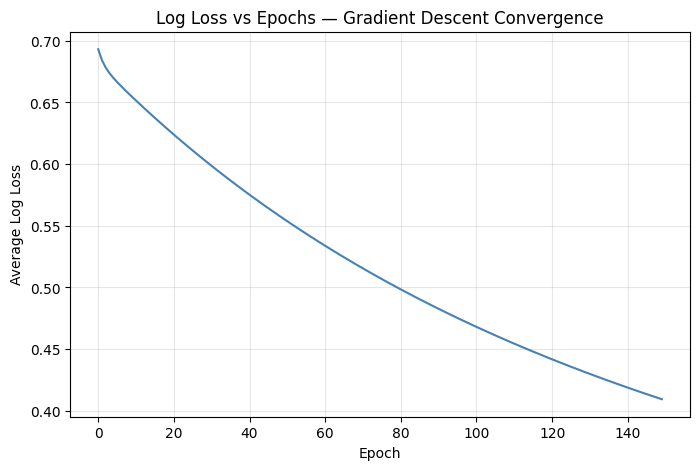

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 0, 0, 1, 1], dtype=float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w, b, lr, epochs = 0.0, 0.0, 0.1, 150
loss_history = []

for epoch in range(epochs):
    z = w * x + b
    y_hat = sigmoid(z)
    loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    loss_history.append(loss)

    error = y_hat - y
    dw = np.mean(error * x)
    db = np.mean(error)
    w -= lr * dw
    b -= lr * db

print(f"Epoch 1 loss  : {loss_history[0]:.4f}  (matches hand calc: 0.693)")
print(f"Epoch 2 loss  : {loss_history[1]:.4f}  (matches hand calc: 0.684)")
print(f"Epoch 150 loss: {loss_history[-1]:.4f}")
print(f"\nFinal w={w:.4f}, b={b:.4f}")
print("\nFinal predictions:")
for xi, yi, yhi in zip(x, y, sigmoid(w*x+b)):
    print(f"  hours={xi:.0f}  actual={yi:.0f}  predicted_prob={yhi:.4f}")

plt.figure(figsize=(8,5))
plt.plot(loss_history, color='steelblue')
plt.title("Log Loss vs Epochs — Gradient Descent Convergence")
plt.xlabel("Epoch")
plt.ylabel("Average Log Loss")
plt.grid(alpha=0.3)
plt.savefig('hand_solved_convergence.png', bbox_inches='tight')
plt.show()

**Reading the curve:** loss decreases smoothly with no jumps — a sign of
healthy training. As training continues, students A/B/C (who failed) get
probabilities pushed toward 0, and D/E (who passed) get pushed toward 1 — the
model has learned "more study hours → higher pass probability" purely from
data, with no rule hand-coded.


<a id="section6"></a>
## 6️⃣ Decision Boundary & Threshold — A Common Misconception

A common misunderstanding: does the model directly output 0 or 1? **No.**

```
Model's actual output (Sigmoid):     After applying a threshold:
    ŷ = 0.73  <- continuous!             -> "Positive" class
    ŷ = 0.12  <- continuous!             -> "Negative" class
    ŷ = 0.51  <- continuous, barely!     -> "Positive" (just barely)
```

The Sigmoid output is **always a continuous decimal strictly between 0 and 1**
— it mathematically never becomes exactly 0 or 1. The threshold (commonly 0.5)
is a **separate, human-chosen rule** applied only at prediction time to convert
that continuous probability into a discrete label. It plays **no role** in the
training loop — training only ever cares about minimizing Log Loss on the
continuous probability.


<a id="section7"></a>
## 7️⃣ Regularization: Ridge vs Lasso vs ElasticNet

Ridge and Lasso aren't separate algorithms — they're an **extra penalty**
added on top of the same linear/logistic formula, to keep weights from
growing too large (which fights overfitting).

| Type | What it does |
|---|---|
| **None (plain)** | No restriction on weight size |
| **Ridge (L2 penalty)** | Shrinks large weights toward zero, but rarely to exactly zero |
| **Lasso (L1 penalty)** | Can shrink weights to **exactly zero** — effectively performing automatic feature selection |
| **ElasticNet** | A blend of both L1 and L2 |

scikit-learn's `LogisticRegression()` uses **L2 (Ridge-style)** by default
(`penalty='l2'`). `GridSearchCV` (Section 10.8) lets us systematically compare
all of these and pick the best one for our data.


<a id="section8"></a>
## 8️⃣ Precision, Recall & the Trade-off

Accuracy alone can be misleading — especially with imbalanced classes (e.g. a
rare disease). If only 2% of patients truly have a disease, a model that
always predicts "healthy" scores 98% accuracy while being completely useless.

### The Confusion Matrix

|                    | Actual: Positive        | Actual: Negative        |
|--------------------|--------------------------|--------------------------|
| **Predicted: Positive** | ✅ True Positive (TP)   | ❌ False Positive (FP)  |
| **Predicted: Negative** | ❌ False Negative (FN)  | ✅ True Negative (TN)   |

- **Precision** — "Of everything I predicted positive, how often was I right?"
$$\text{Precision} = \frac{TP}{TP + FP}$$
- **Recall** — "Of everything that was actually positive, how many did I catch?"
$$\text{Recall} = \frac{TP}{TP + FN}$$

**Trade-off:** raising the decision threshold increases Precision but lowers
Recall, and vice versa. Which matters more depends on context:
- **Medical diagnosis** → prioritize **Recall** (missing a sick patient is far worse than a false alarm).
- **Spam filtering** → prioritize **Precision** (flagging an important email as spam is worse than letting one spam email through).

When both matter, use the **F1-Score** (their harmonic mean).


<a id="section9"></a>
## 9️⃣ Bias-Variance Tradeoff (Quick Note)

This concept applies to **all** models (regression and classification alike),
not just Logistic Regression:

- **High Bias (Underfitting)** — the model is too simple to capture the real
  pattern; it performs poorly even on training data.
- **High Variance (Overfitting)** — the model is overly complex and memorizes
  noise in the training data; it looks perfect on training data but fails on
  new, unseen data.

The goal is a **sweet spot**: simple enough to generalize, complex enough to
capture the real signal. Regularization (Section 7) is one of the main tools
used to manage this trade-off.


<a id="section10"></a>
## 🔟 Building the Real Project — Heart Disease Prediction

In [2]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv


### 10.1 — Data Loading & Understanding

In [3]:
df = pd.read_csv('/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
print('Missing values per columns:', df.isnull().sum())
print('\n Duplicated rows:', df.duplicated().sum())

Missing values per columns: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

 Duplicated rows: 723


**Why check for duplicates carefully:** an exact duplicate row (every
single column matching) usually means the same patient record was copy-pasted
into the dataset. If left in, the same patient can end up in both the training
and test sets — a form of **data leakage** that makes evaluation metrics
falsely optimistic. Always drop exact duplicates before splitting the data.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [8]:
print("Shape before:", df.shape)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after:", df.shape)

Shape before: (1025, 14)
Shape after: (302, 14)


### 10.2 — Univariate Analysis

We look at each column **in isolation** first — how is it distributed, and
does anything look unusual?

**Why we can't use `select_dtypes` to auto-detect numeric vs categorical
columns here:** several categorical columns (`sex`, `cp`, `fbs`, `restecg`,
`exang`, `slope`, `ca`, `thal`) are stored as integers (`int64`), exactly like
genuinely continuous columns. `dtype` only tells us *how* data is stored, not
*what it means* — that requires domain knowledge. We manually specify the two
lists below based on understanding what each column represents.

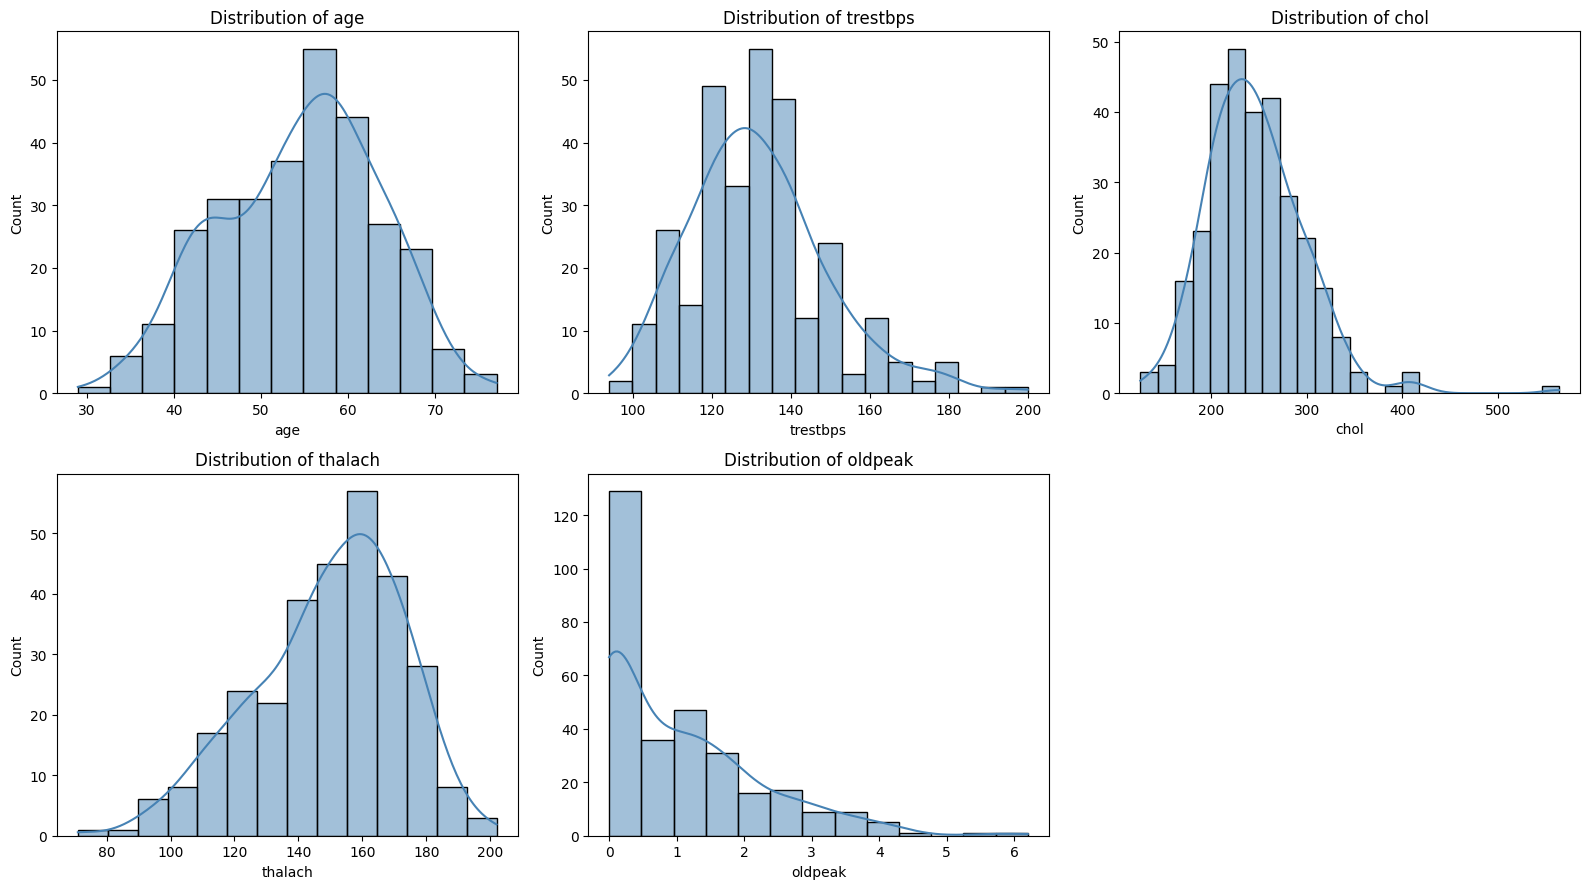

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

for i , col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('01_univariate_numeric.png', bbox_inches='tight')
plt.show()

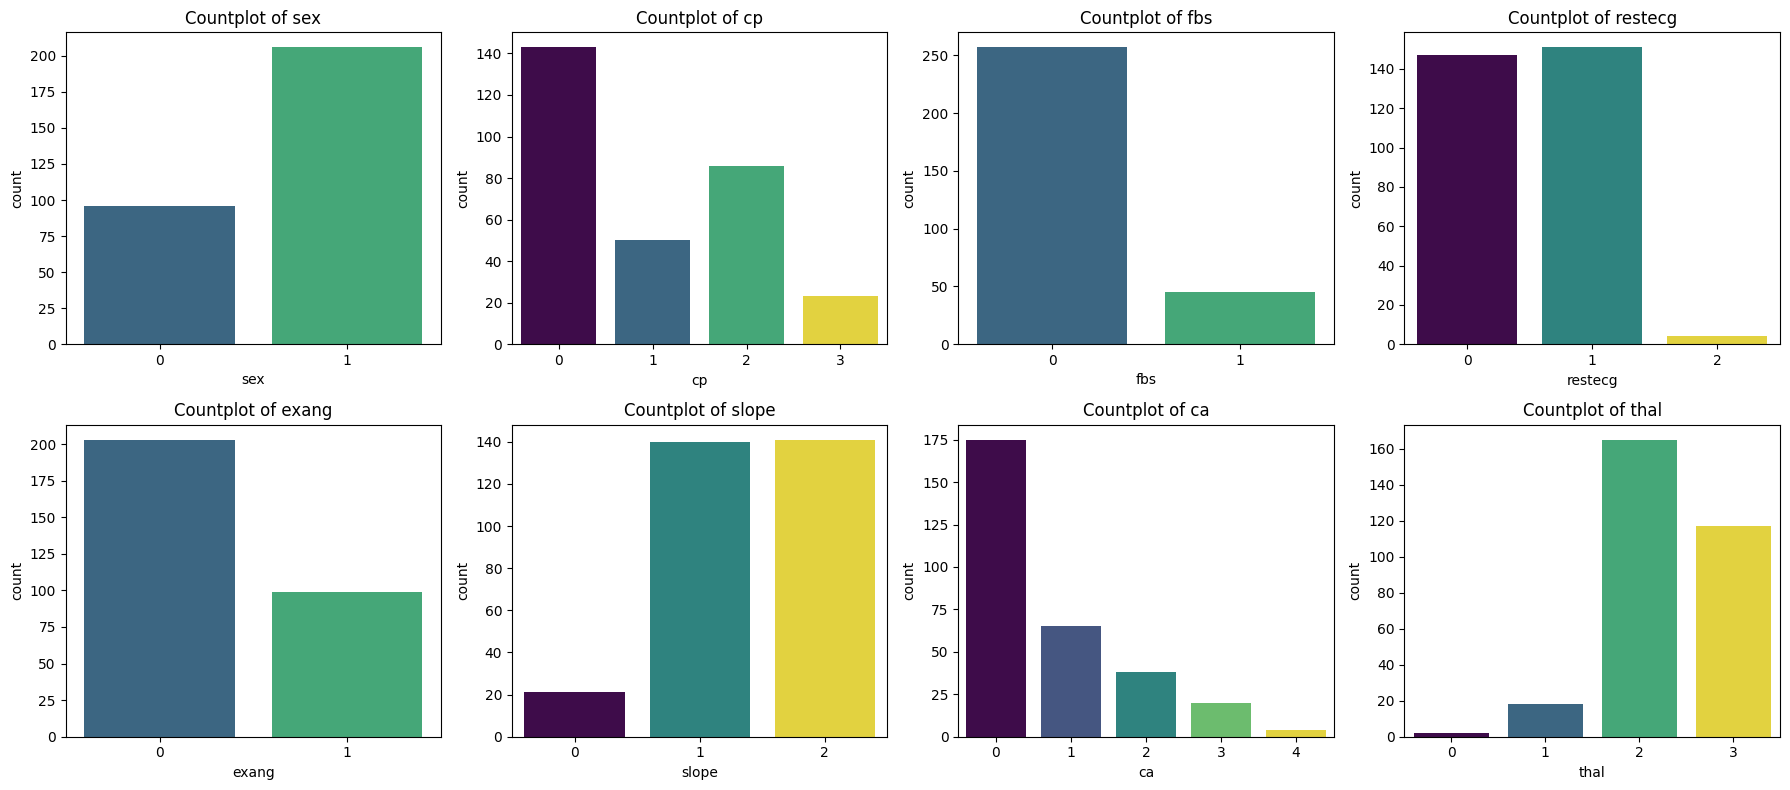

In [10]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i], hue=df[col], palette='viridis', legend=False)
    axes[i].set_title(f'Countplot of {col}')
plt.tight_layout()
plt.savefig('02_univariate_categorical.png', bbox_inches='tight')
plt.show()

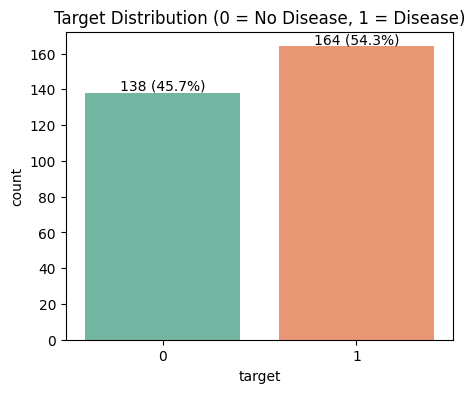

target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='target', data=df, hue='target', palette='Set2', legend=False)
plt.title('Target Distribution (0 = No Disease, 1 = Disease)')
for p in ax.patches:
    pct = 100 * p.get_height() / len(df)
    ax.annotate(f'{int(p.get_height())} ({pct:.1f}%)', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.savefig('03_target_distribution.png', bbox_inches='tight')
plt.show()
print(df['target'].value_counts(normalize=True) * 100)

**Observations:**
- `age`, `trestbps`, `chol`, `thalach` are roughly bell-shaped.
- `oldpeak` is right-skewed with a few outliers on the high end.
- The target is roughly balanced (~54% vs ~46%), so accuracy is a reasonably
  meaningful metric here (though we'll still track Precision/Recall/F1).

### 10.3 — Bivariate Analysis

Now we ask: **how does each feature relate to the target?**


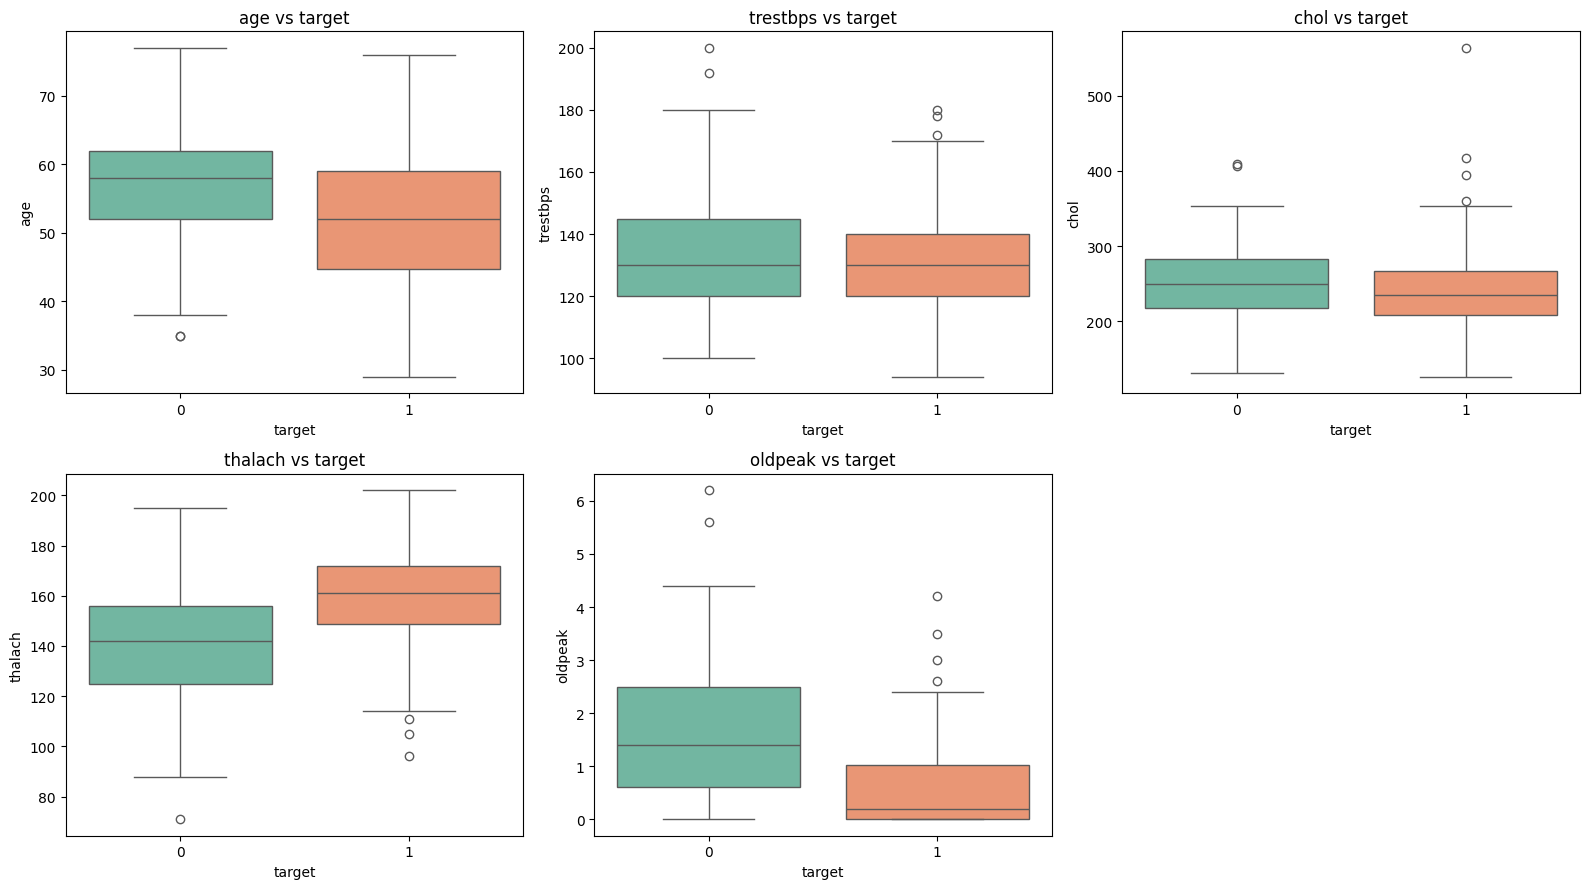

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x='target', y=col, data=df, hue='target', palette='Set2', legend=False, ax=axes[i])
    axes[i].set_title(f'{col} vs target')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('04_bivariate_numeric_boxplots.png', bbox_inches='tight')
plt.show()

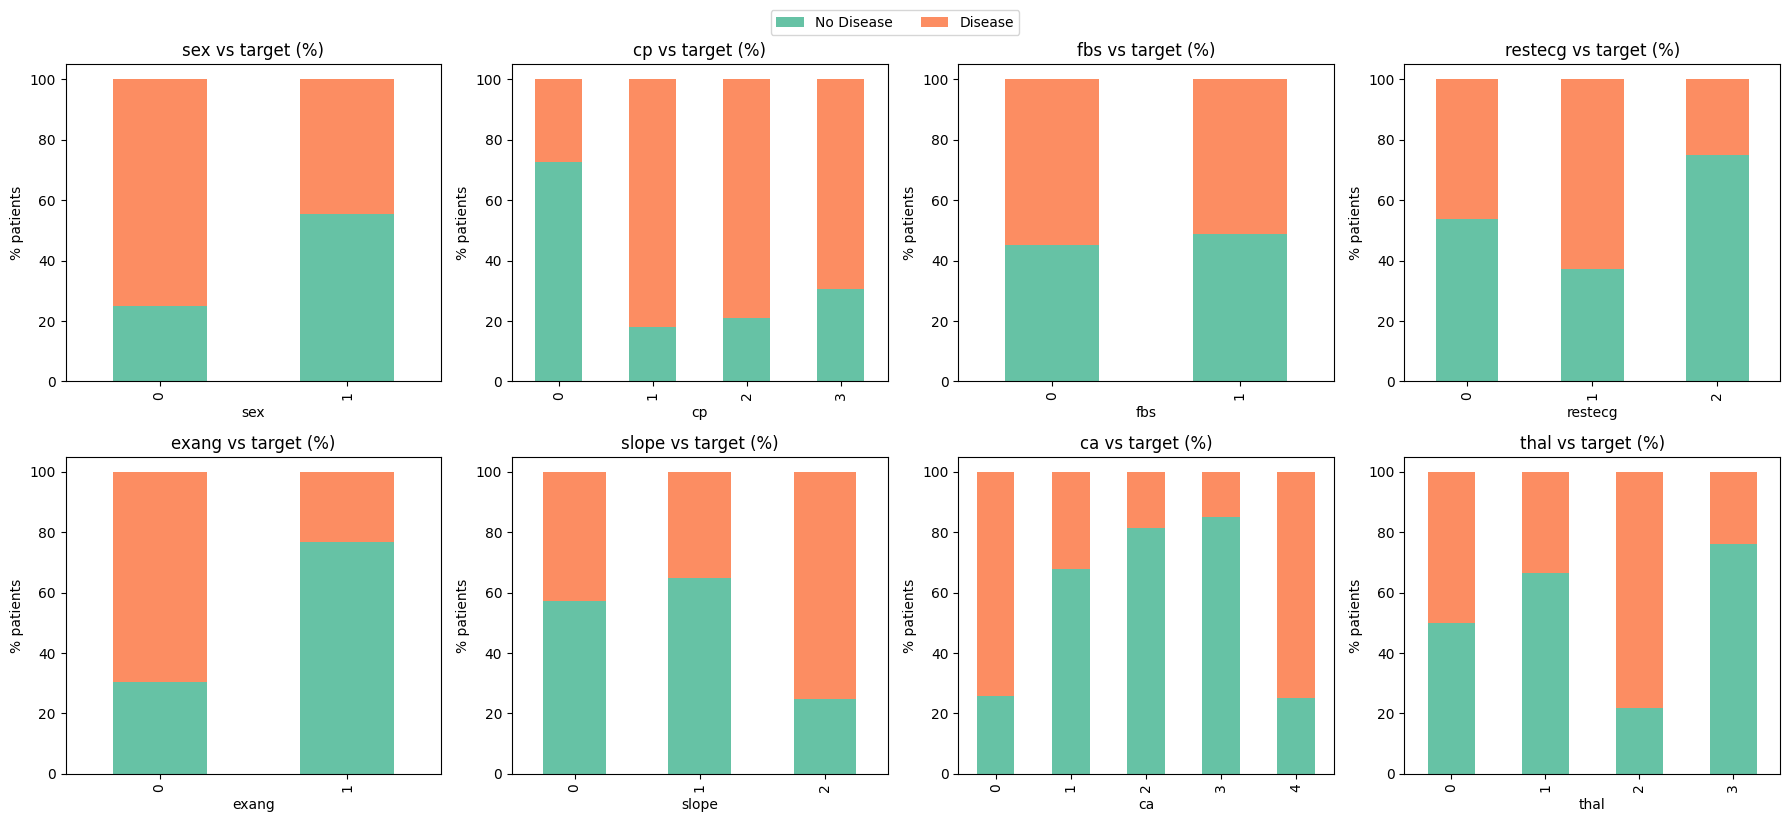

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#66c2a5', '#fc8d62'], legend=False)
    axes[i].set_title(f'{col} vs target (%)')
    axes[i].set_ylabel('% patients')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['No Disease', 'Disease'], loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.03))
plt.tight_layout()
plt.savefig('05_bivariate_categorical.png', bbox_inches='tight')
plt.show()

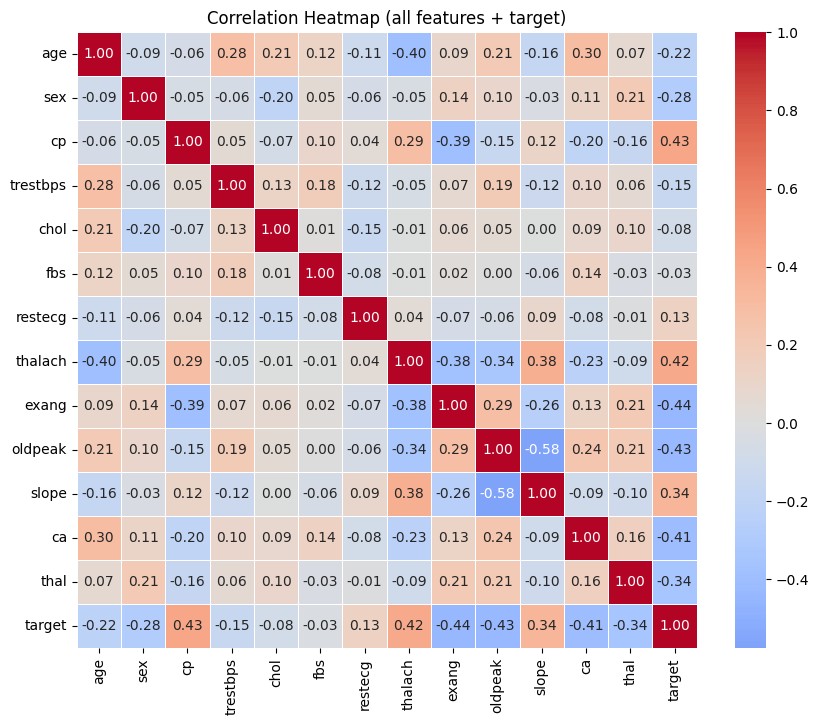

In [14]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap (all features + target)')
plt.savefig('06_correlation_heatmap.png', bbox_inches='tight')
plt.show()

**Reading a correlation heatmap:** each cell is the Pearson correlation
coefficient (-1 to +1) between two columns. Values near the target row/column
show feature relevance (linear relationships only); off-diagonal values
between two features flag potential **multicollinearity** (redundant
information) — important mainly for linear-family models like Logistic
Regression, much less so for tree-based models, which handle correlated
features natively.


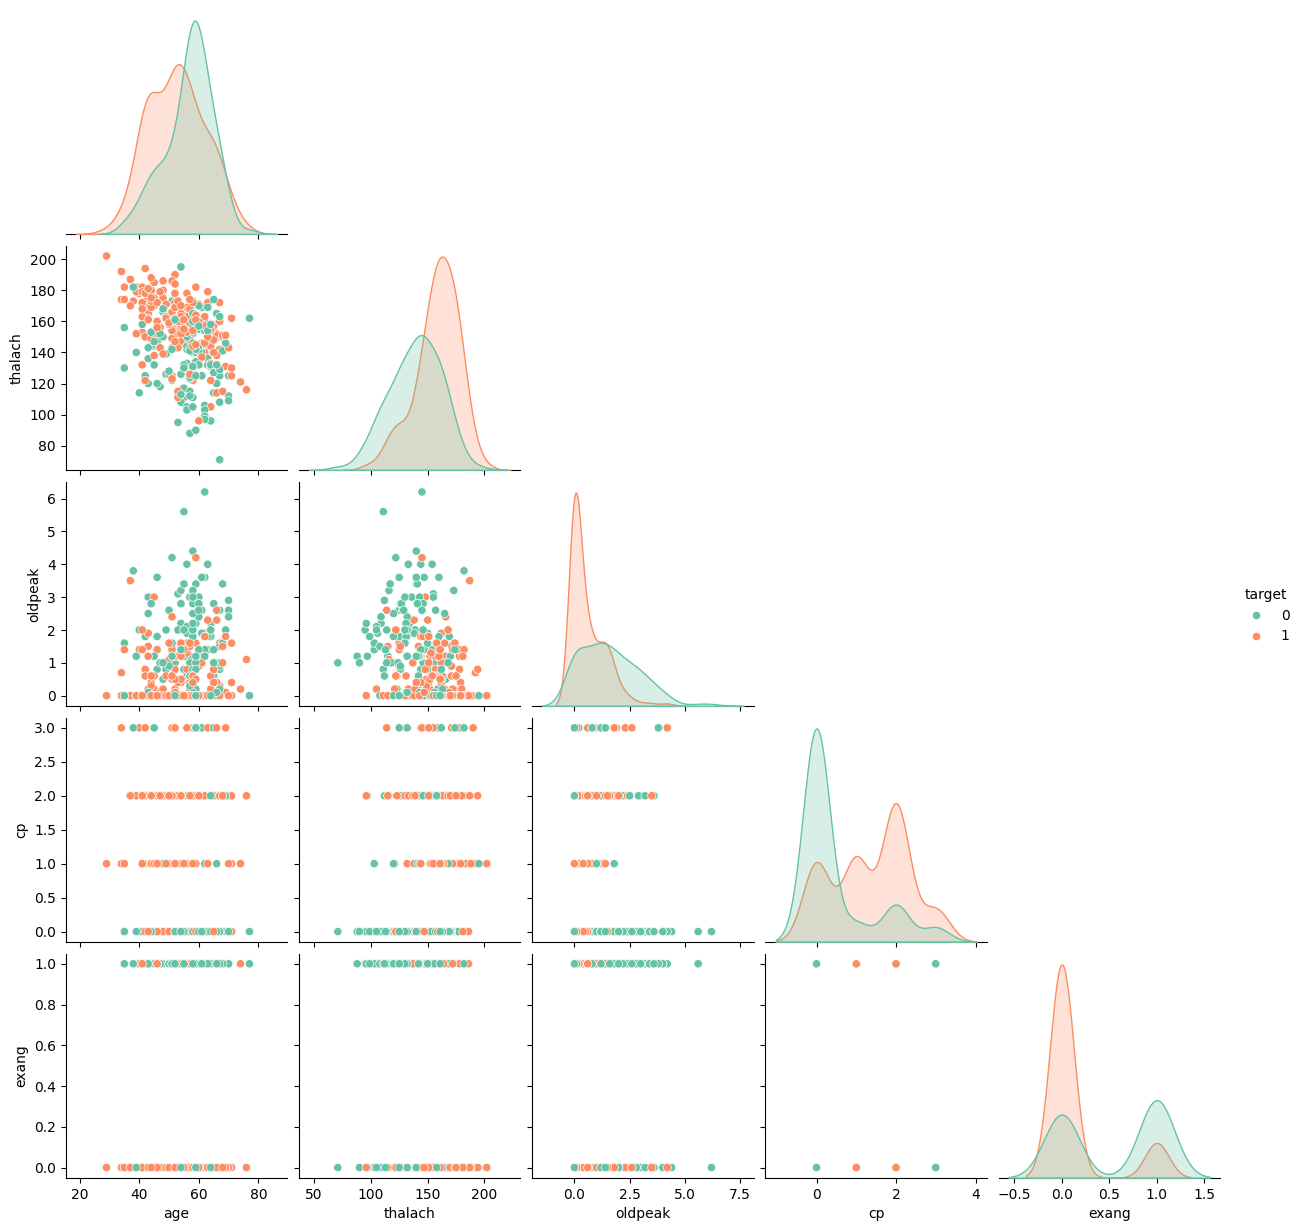

In [15]:
strong_features = ['age', 'thalach', 'oldpeak', 'cp', 'exang']
sns.pairplot(df[strong_features + ['target']], hue='target', palette='Set2', corner=True)
plt.savefig('07_pairplot.png', bbox_inches='tight')
plt.show()

*(Note: these five features were picked informally, based on what the
correlation heatmap and crosstabs above already flagged as promising — this is
just for a readable visualization, not the formal Feature Selection step,
which comes next and considers all 13 features.)*

### 10.4 — Feature Engineering

In [16]:
df_fe = df.copy()
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 40, 50, 60, 100], labels=['<40','40-50','50-60','60+'])
df_fe['chol_level'] = pd.cut(df_fe['chol'], bins=[0, 200, 240, 1000], labels=['normal','borderline','high'])
df_fe['exercise_risk_score'] = df_fe['exang'] * df_fe['oldpeak']
df_fe['hr_reserve'] = (220 - df_fe['age']) - df_fe['thalach']

df_fe[['age','age_group','chol','chol_level','exercise_risk_score','hr_reserve']].head()


,age,age_group,chol,chol_level,exercise_risk_score,hr_reserve
0,52,50-60,212,borderline,0.0,0
1,53,50-60,203,borderline,3.1,12
2,70,60+,174,normal,2.6,25
3,61,60+,203,borderline,0.0,-2
4,62,60+,294,high,0.0,52


### 10.5 — Feature Selection

**Multicollinearity check (VIF)** — flags features that carry mostly redundant
information relative to others (VIF > 5–10 is typically considered high):

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = numeric_cols + ['exercise_risk_score', 'hr_reserve']
X_vif = df_fe[vif_features].copy()
vif_df = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_df


,feature,VIF
0,thalach,42.204315
1,age,36.982461
2,hr_reserve,2.544780
3,oldpeak,1.800368
4,exercise_risk_score,1.794440
5,trestbps,1.131183
6,chol,1.060023


The engineered features derived directly from raw columns can show high
VIF against their "parent" columns — so we keep the original raw features
(they're more interpretable and VIF-safe) rather than adding both.

**Statistical relevance** — ANOVA F-test for numeric features, Mutual
Information for categorical features:


In [18]:
from sklearn.feature_selection import f_classif, mutual_info_classif

f_scores, f_pvals = f_classif(df[numeric_cols], df['target'])
num_relevance = pd.DataFrame({'feature': numeric_cols, 'F_score': f_scores, 'p_value': f_pvals})\
                  .sort_values('F_score', ascending=False)

mi_scores = mutual_info_classif(df[categorical_cols], df['target'], discrete_features=True, random_state=42)
cat_relevance = pd.DataFrame({'feature': categorical_cols, 'MI_score': mi_scores})\
                   .sort_values('MI_score', ascending=False)

print("Numeric features ranked (ANOVA F-test):")
display(num_relevance)
print("\nCategorical features ranked (Mutual Information):")
display(cat_relevance)


Numeric features ranked (ANOVA F-test):


,feature,F_score,p_value
4,oldpeak,67.721931,5.814567e-15
3,thalach,64.237793,2.476146e-14
0,age,15.474511,1.039484e-04
1,trestbps,6.558676,1.092654e-02
2,chol,2.002888,1.580370e-01



Categorical features ranked (Mutual Information):


,feature,MI_score
7,thal,0.147099
1,cp,0.141042
6,ca,0.128142
4,exang,0.098085
5,slope,0.080175
0,sex,0.041769
3,restecg,0.016254
2,fbs,0.000359


**Decision:** all 13 original features are clinically meaningful and
none show severe multicollinearity — we carry all of them forward into the
model.

### 10.6 — Preprocessing Pipeline (ColumnTransformer)

- **Numeric columns** → `StandardScaler` (puts them on comparable scales).
- **Categorical columns** → `OneHotEncoder` (since values like `cp=2` are
  labels, not magnitudes — treating them as raw numbers would wrongly imply an
  order/scale).


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

preprocessor

Train shape: (241, 13)  Test shape: (61, 13)


ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'trestbps', 'chol', 'thalach',
                                  'oldpeak']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['sex', 'cp', 'fbs', 'restecg', 'exang',
                                  'slope', 'ca', 'thal'])])

### 10.7 — Baseline Model + Cross-Validation


In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate

baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = cross_validate(baseline_pipe, X_train, y_train, cv=cv, scoring=scoring)

baseline_summary = pd.DataFrame({
    m: [cv_results[f'test_{m}'].mean(), cv_results[f'test_{m}'].std()] for m in scoring
}, index=['mean', 'std']).T
baseline_summary


,mean,std
accuracy,0.846173,0.060208
precision,0.853175,0.082978
recall,0.885185,0.080957
f1,0.862895,0.048930
roc_auc,0.924683,0.036230
